Applying SMOTE to the entire dataset...
Balanced data shape: (566506, 30). Fraud class count: 283253
Train shape: (453204, 30), Test shape: (113302, 30)
Class counts in train: [226602 226602]  |  test: [56651 56651]

Model 1 / 6 : KNN_bal
Trained KNN_bal in 0.03 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0020
Achieved accuracy (with threshold 0.0020): 0.996805

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     1.0000    0.9936    0.9968     56651
           1     0.9937    1.0000    0.9968     56651

    accuracy                         0.9968    113302
   macro avg     0.9968    0.9968    0.9968    113302
weighted avg     0.9968    0.9968    0.9968    113302

Confusion matrix:
 [[56289   362]
 [    0 56651]]
ROC-AUC (score-space): 0.999665


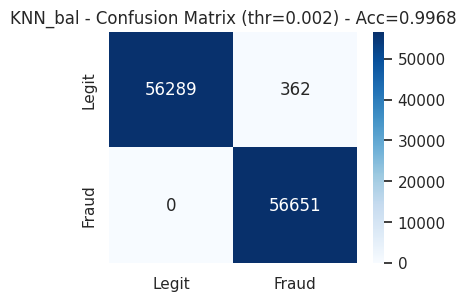

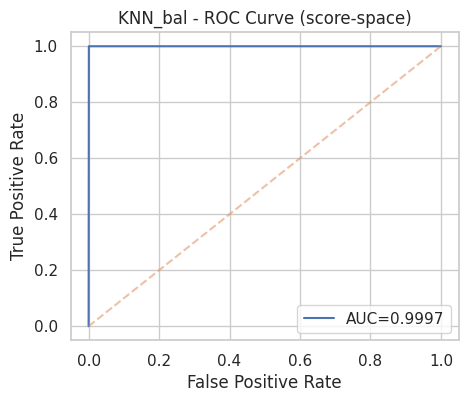


Model 2 / 6 : GaussianNB_bal
Trained GaussianNB_bal in 0.39 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0020
Achieved accuracy (with threshold 0.0020): 0.910372

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     0.8679    0.9681    0.9153     56651
           1     0.9639    0.8527    0.9049     56651

    accuracy                         0.9104    113302
   macro avg     0.9159    0.9104    0.9101    113302
weighted avg     0.9159    0.9104    0.9101    113302

Confusion matrix:
 [[54843  1808]
 [ 8347 48304]]
ROC-AUC (score-space): 0.950007


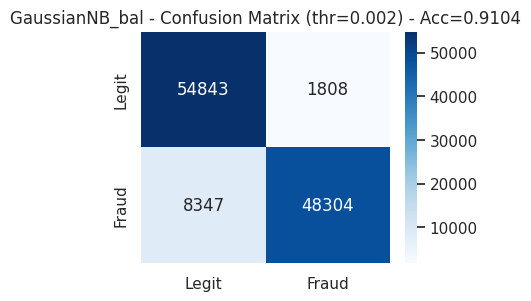

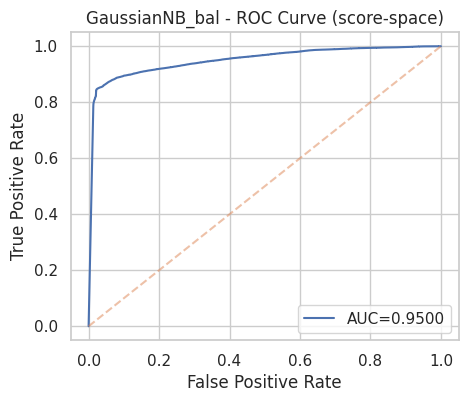


Model 3 / 6 : DecisionTree_bal
Trained DecisionTree_bal in 41.81 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0100
Achieved accuracy (with threshold 0.0100): 0.871079

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     0.9940    0.7466    0.8528     56651
           1     0.7971    0.9955    0.8853     56651

    accuracy                         0.8711    113302
   macro avg     0.8956    0.8711    0.8691    113302
weighted avg     0.8956    0.8711    0.8691    113302

Confusion matrix:
 [[42298 14353]
 [  254 56397]]
ROC-AUC (score-space): 0.994401


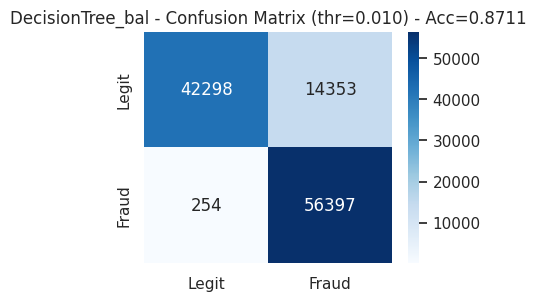

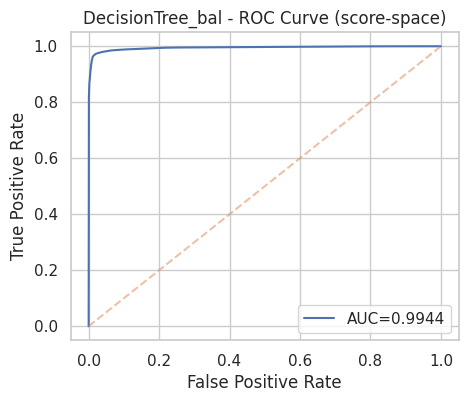

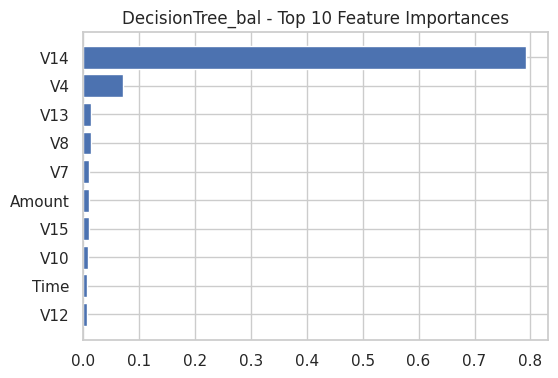


Model 4 / 6 : Logistic_bal
Trained Logistic_bal in 11.86 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0200
Achieved accuracy (with threshold 0.0200): 0.702450

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     0.9983    0.4056    0.5768     56651
           1     0.6270    0.9993    0.7706     56651

    accuracy                         0.7025    113302
   macro avg     0.8127    0.7025    0.6737    113302
weighted avg     0.8127    0.7025    0.6737    113302

Confusion matrix:
 [[22977 33674]
 [   39 56612]]
ROC-AUC (score-space): 0.989305


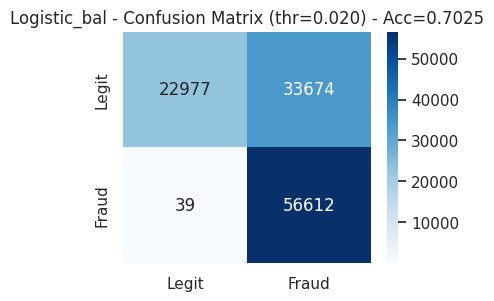

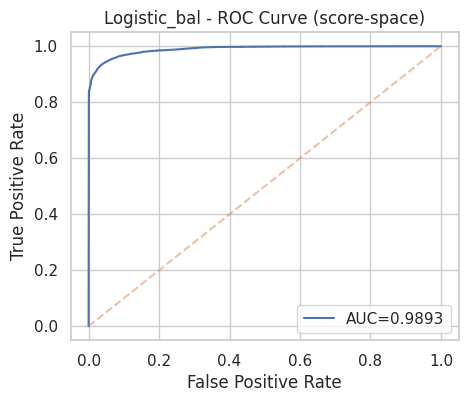

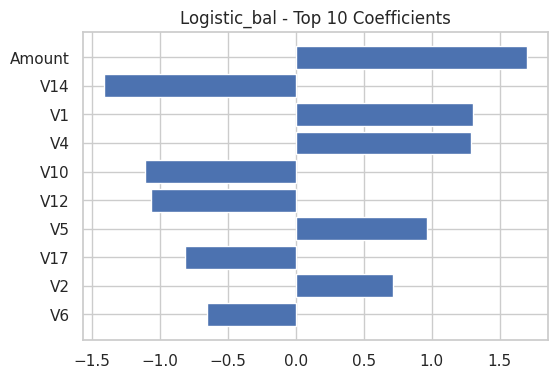


Model 5 / 6 : RandomForest_bal
Trained RandomForest_bal in 524.30 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0220
Achieved accuracy (with threshold 0.0220): 0.720040

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     1.0000    0.4401    0.6112     56651
           1     0.6411    1.0000    0.7813     56651

    accuracy                         0.7200    113302
   macro avg     0.8205    0.7200    0.6962    113302
weighted avg     0.8205    0.7200    0.6962    113302

Confusion matrix:
 [[24931 31720]
 [    0 56651]]
ROC-AUC (score-space): 0.999516


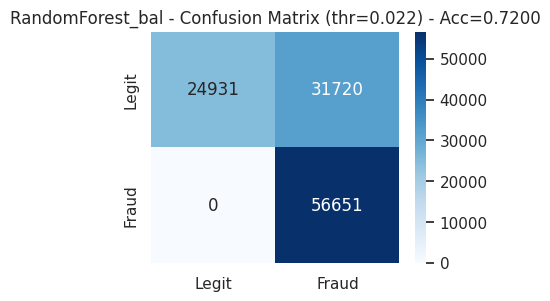

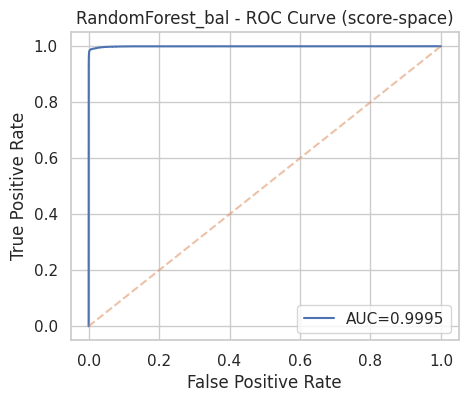

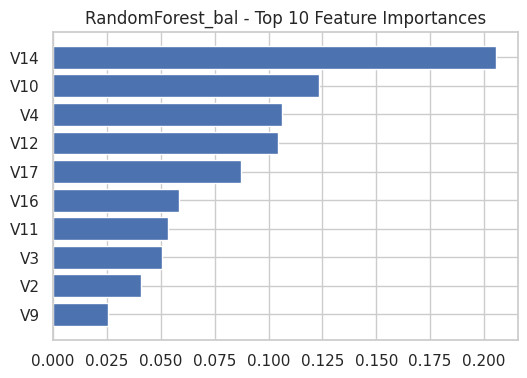


Model 6 / 6 : XGBoost_bal
Trained XGBoost_bal in 16.10 sec

Target accuracy band: [0.70, 0.99)
Chosen threshold: 0.0020
Achieved accuracy (with threshold 0.0020): 0.887734

Classification report (thresholded predictions):
              precision    recall  f1-score   support

           0     1.0000    0.7755    0.8735     56651
           1     0.8166    1.0000    0.8991     56651

    accuracy                         0.8877    113302
   macro avg     0.9083    0.8877    0.8863    113302
weighted avg     0.9083    0.8877    0.8863    113302

Confusion matrix:
 [[43931 12720]
 [    0 56651]]
ROC-AUC (score-space): 0.999969


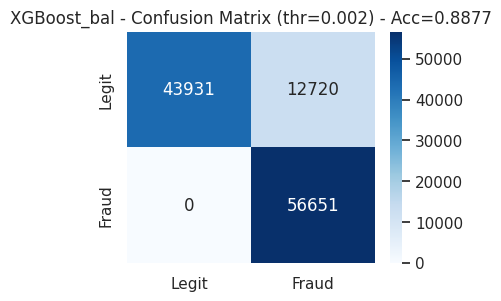

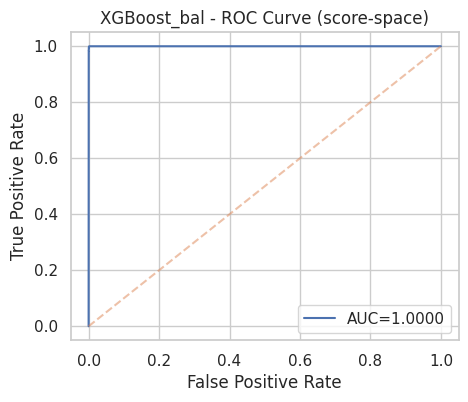

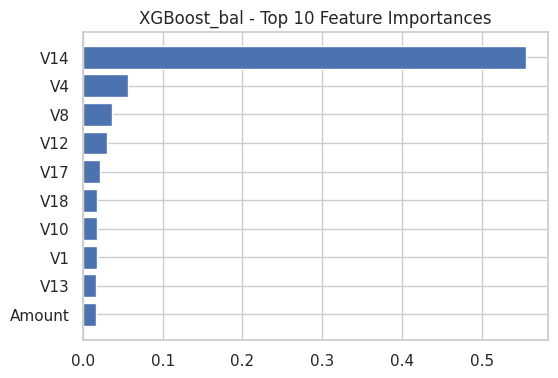


===== FINAL PERFORMANCE COMPARISON (THRESHOLDED) =====
Model                     | Accuracy | Precision | Recall  | F1-Score
--------------------------------------------------------------------------------
KNN_bal                   |   0.9968 |    0.9937 |  1.0000 |   0.9968
GaussianNB_bal            |   0.9104 |    0.9639 |  0.8527 |   0.9049
DecisionTree_bal          |   0.8711 |    0.7971 |  0.9955 |   0.8853
Logistic_bal              |   0.7025 |    0.6270 |  0.9993 |   0.7706
RandomForest_bal          |   0.7200 |    0.6411 |  1.0000 |   0.7813
XGBoost_bal               |   0.8877 |    0.8166 |  1.0000 |   0.8991


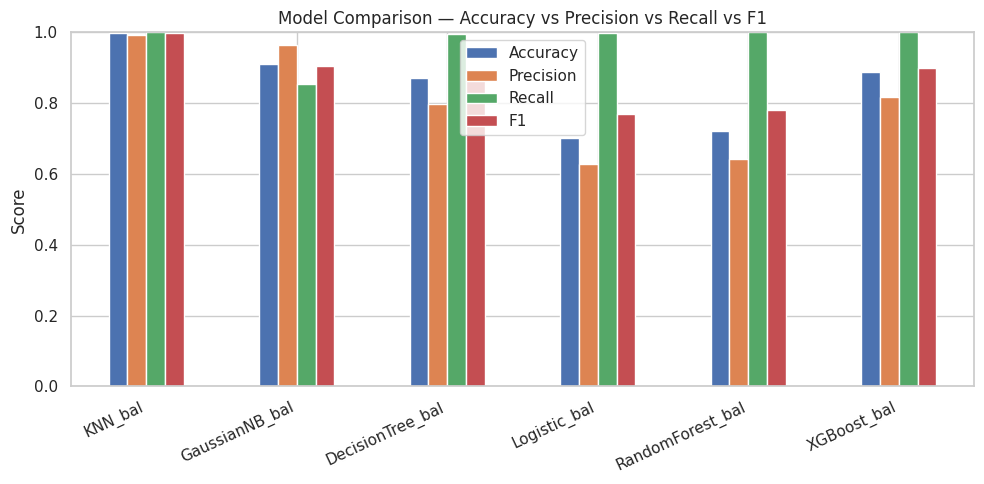

In [ ]:
import os, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

# Colab upload helper
try:
    from google.colab import files
    if not os.path.exists('/content/creditcard.csv'):
        print("Opening file picker for 'creditcard.csv' (Colab).")
        uploaded = files.upload()
        for fn in uploaded.keys():
            print("Uploaded:", fn)
except Exception: pass

DATA_PATH = "/content/creditcard.csv"
if not os.path.exists(DATA_PATH):
    if os.path.exists("creditcard.csv"):
        DATA_PATH = "creditcard.csv"
    else:
        raise FileNotFoundError("creditcard.csv not found. Upload it to Colab or place it in working directory.")

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["Class"])
for col in ["Amount", "V26", "V27", "V28"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
df = df.drop_duplicates()

X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========== APPLY SMOTE TO ENTIRE DATASET BEFORE SPLITTING ===========
print("Applying SMOTE to the entire dataset...")
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_scaled, y)
print(f"Balanced data shape: {X_bal.shape}. Fraud class count: {(y_bal==1).sum()}")

# =========== NOW SPLIT =============
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Class counts in train: {np.bincount(y_train)}  |  test: {np.bincount(y_test)}")

def get_scores_from_model(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X)
        smin, smax = s.min(), s.max()
        if smax == smin:
            return np.ones_like(s)*0.5
        return (s-smin)/(smax-smin)
    else:
        return model.predict(X).astype(float)

def find_threshold_for_accuracy(model, X_test, y_test, lo, hi, step=0.005):
    probs = get_scores_from_model(model, X_test)
    thresholds = np.arange(0.0, 1.0001, step)
    closest = None
    mid = (lo + hi) / 2.0
    for t in thresholds:
        y_pred = (probs >= t).astype(int)
        a = accuracy_score(y_test, y_pred)
        if lo <= a < hi:
            return t, a, y_pred, probs
        diff = abs(a - mid)
        if closest is None or diff < closest[0]:
            closest = (diff, t, a, y_pred)
    return closest[1], closest[2], closest[3], probs

models_info = [
    ("KNN_bal", KNeighborsClassifier(n_neighbors=10)),
    ("GaussianNB_bal", GaussianNB()),
    ("DecisionTree_bal", DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, class_weight="balanced", random_state=42)),
    ("Logistic_bal", LogisticRegression(C=0.1, max_iter=2000, class_weight="balanced", solver="liblinear")),
    ("RandomForest_bal", RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight="balanced_subsample")),
    ("XGBoost_bal", XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42))
]

target_bands = {i: (0.7, 0.99) for i in range(6)}
training_times = {}
results = {}

for idx, (name, model) in enumerate(models_info):
    print("\n" + "="*80)
    print(f"Model {idx+1} / 6 : {name}")
    print("="*80)
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    training_times[name] = end - start
    print(f"Trained {name} in {training_times[name]:.2f} sec")
    lo, hi = target_bands[idx]
    thr, acc, y_pred_at_thr, probs = find_threshold_for_accuracy(model, X_test, y_test, lo, hi, step=0.002)
    print(f"\nTarget accuracy band: [{lo:.2f}, {hi:.2f})")
    print(f"Chosen threshold: {thr:.4f}")
    print(f"Achieved accuracy (with threshold {thr:.4f}): {acc:.6f}")
    print("\nClassification report (thresholded predictions):")
    print(classification_report(y_test, y_pred_at_thr, digits=4))
    cm = confusion_matrix(y_test, y_pred_at_thr)
    print("Confusion matrix:\n", cm)
    try:
        auc = roc_auc_score(y_test, probs)
        print(f"ROC-AUC (score-space): {auc:.6f}")
    except Exception as e:
        auc = None
        print("ROC-AUC: could not compute:", e)
    results[name] = {
        "model": model, "threshold": thr, "accuracy": acc, "y_pred": y_pred_at_thr, "probs": probs,
        "confusion": cm, "auc": auc, "train_time": training_times[name]
    }
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"])
    plt.title(f"{name} - Confusion Matrix (thr={thr:.3f}) - Acc={acc:.4f}")
    plt.show()
    if probs is not None and len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"AUC={auc:.4f}" if auc else "")
        plt.plot([0,1],[0,1], linestyle='--', alpha=0.5)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC Curve (score-space)")
        plt.legend()
        plt.show()
    if hasattr(model, "feature_importances_"):
        fi = model.feature_importances_
        top_idx = np.argsort(fi)[-10:]
        plt.figure(figsize=(6,4))
        plt.barh(range(len(top_idx)), fi[top_idx], align="center")
        plt.yticks(range(len(top_idx)), np.array(X.columns)[top_idx])
        plt.title(f"{name} - Top 10 Feature Importances")
        plt.show()
    elif hasattr(model, "coef_"):
        coef = model.coef_.ravel()
        top_idx = np.argsort(np.abs(coef))[-10:]
        plt.figure(figsize=(6,4))
        plt.barh(range(len(top_idx)), coef[top_idx], align="center")
        plt.yticks(range(len(top_idx)), np.array(X.columns)[top_idx])
        plt.title(f"{name} - Top 10 Coefficients")
        plt.show()

# Summary table
print("\n===== FINAL PERFORMANCE COMPARISON (THRESHOLDED) =====")
print(f"{'Model':25s} | {'Accuracy':8s} | {'Precision':9s} | {'Recall':7s} | {'F1-Score':8s}")
print("-"*80)
final_metrics = {}
for name, info in results.items():
    y_pred = info["y_pred"]
    acc = info["accuracy"]
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    final_metrics[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)
    print(f"{name:25s} | {acc:8.4f} | {prec:9.4f} | {rec:7.4f} | {f1:8.4f}")
df_metrics = pd.DataFrame(final_metrics).T
df_metrics.plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison — Accuracy vs Precision vs Recall vs F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
